In [ ]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
# Configuración de conexión (tu misma)

DB_CONFIG = {
    'host': os.getenv("POSTGRES_HOST"),
    'database': os.getenv("POSTGRES_DB"),
    'user': os.getenv("POSTGRES_USER"),
    'password': os.getenv("POSTGRES_PASSWORD"),
    'port': int(os.getenv("POSTGRES_PORT"))
}
# Conexión
conexion = psycopg2.connect(**DB_CONFIG)

print("Conectado a PostgreSQL")

Conectado a PostgreSQL


## ________________________________________________________________
## **QUERY 1 – Vehiculos activos y ultimo mantenimiento**

## **Problema de negocio**

**FleetLogix necesita garantizar que su flota se encuentre en condiciones óptimas de operación, ya que los vehículos son el activo principal del negocio logístico. Un mantenimiento inadecuado puede generar retrasos en entregas, mayores costos operativos y pérdida de confianza por parte de los clientes. Por ello, es fundamental identificar cuáles vehículos se encuentran activos y conocer la fecha de su último mantenimiento, con el fin de anticipar posibles fallas y planificar mantenimientos preventivos de manera eficiente.**

In [13]:
query1 = """
SELECT 
    v.vehicle_id,
    v.license_plate,
    v.vehicle_type,
    v.status,
    MAX(m.maintenance_date) AS last_maintenance_date
FROM vehicles v
LEFT JOIN maintenance m 
    ON v.vehicle_id = m.vehicle_id
WHERE v.status = 'active'
GROUP BY v.vehicle_id, v.license_plate, v.vehicle_type, v.status
ORDER BY last_maintenance_date DESC;
"""
df1 = pd.read_sql(query1, conexion)
df1.head()

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\2359025616.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(query1, conexion)


,vehicle_id,license_plate,vehicle_type,status,last_maintenance_date
0,363,VQR402,Camión Mediano,active,2026-01-25
1,296,KYC614,Camión Mediano,active,2026-01-25
2,272,GRO319,Van,active,2026-01-24
3,268,NNO325,Camión Grande,active,2026-01-24
4,333,LXZ315,Van,active,2026-01-24


In [14]:
query1_explain = "EXPLAIN ANALYZE " + query1
plan1 = pd.read_sql(query1_explain, conexion)
print("\n".join(plan1['QUERY PLAN']))

Sort  (cost=185.02..185.47 rows=181 width=33) (actual time=1.578..1.584 rows=181 loops=1)
  Sort Key: (max(m.maintenance_date)) DESC
  Sort Method: quicksort  Memory: 34kB
  ->  HashAggregate  (cost=176.42..178.23 rows=181 width=33) (actual time=1.528..1.546 rows=181 loops=1)
        Group Key: v.vehicle_id
        Batches: 1  Memory Usage: 64kB
        ->  Hash Right Join  (cost=6.76..154.16 rows=4453 width=33) (actual time=0.080..1.038 rows=4920 loops=1)
              Hash Cond: (m.vehicle_id = v.vehicle_id)
              ->  Seq Scan on maintenance m  (cost=0.00..134.20 rows=4920 width=8) (actual time=0.005..0.216 rows=4920 loops=1)
              ->  Hash  (cost=4.50..4.50 rows=181 width=29) (actual time=0.064..0.064 rows=181 loops=1)
                    Buckets: 1024  Batches: 1  Memory Usage: 19kB
                    ->  Seq Scan on vehicles v  (cost=0.00..4.50 rows=181 width=29) (actual time=0.017..0.041 rows=181 loops=1)
                          Filter: ((status)::text = 'activ

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\228103979.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plan1 = pd.read_sql(query1_explain, conexion)


## **Análisis de resultados**
**La consulta devuelve un total de 181 vehículos activos junto con la fecha de su último mantenimiento y 19 vehículos en matenimiento (tomar en cuenta para no considerar en los pedidos). Se observa que varios vehículos presentan fechas recientes de mantenimiento, como por ejemplo el 25 de enero de 2026 en el caso de algunos camiones medianos**

**El plan de ejecución muestra un tiempo total de 1.640 ms, lo cual indica que la consulta es altamente eficiente. PostgreSQL realiza un escaneo secuencial (Seq Scan) sobre la tabla vehicles para filtrar los vehículos activos, lo cual es adecuado dado el bajo volumen de registros**

## ________________________________________________________________
## **QUERY 2 – Total de viajes por conductor**

## **Problema de negocio**

**En una empresa logística como FleetLogix, es fundamental monitorear la carga de trabajo de los conductores para garantizar una operación equilibrada y eficiente. Una distribución inadecuada de los viajes puede generar sobrecarga laboral en algunos conductores, mientras que otros podrían estar siendo subutilizados. Esta consulta permite analizar la cantidad de viajes realizados por cada conductor, proporcionando información clave para optimizar la asignación de recursos humanos.**

In [15]:
query2 = """
SELECT 
    d.driver_id,
    d.first_name,
    d.last_name,
    COUNT(t.trip_id) AS total_trips
FROM drivers d
LEFT JOIN trips t 
    ON d.driver_id = t.driver_id
GROUP BY d.driver_id, d.first_name, d.last_name
ORDER BY total_trips DESC;
"""

df2 = pd.read_sql(query2, conexion)
df2.head()

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\3957712076.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(query2, conexion)


,driver_id,first_name,last_name,total_trips
0,613,Carmen,Blanco,311
1,537,Yaneth,Castrillón,311
2,717,Luz,Castro,308
3,662,Dairo,Zapata,302
4,437,Humberto,Cerón,302


In [16]:
query2_explain = "EXPLAIN ANALYZE " + query2
plan2 = pd.read_sql(query2_explain, conexion)
print("\n".join(plan2['QUERY PLAN']))

Sort  (cost=2831.57..2832.57 rows=400 width=26) (actual time=29.084..29.095 rows=400 loops=1)
  Sort Key: (count(t.trip_id)) DESC
  Sort Method: quicksort  Memory: 43kB
  ->  HashAggregate  (cost=2810.28..2814.28 rows=400 width=26) (actual time=28.986..29.020 rows=400 loops=1)
        Group Key: d.driver_id
        Batches: 1  Memory Usage: 93kB
        ->  Hash Right Join  (cost=14.00..2310.28 rows=100000 width=22) (actual time=0.117..18.041 rows=100027 loops=1)
              Hash Cond: (t.driver_id = d.driver_id)
              ->  Seq Scan on trips t  (cost=0.00..2031.00 rows=100000 width=8) (actual time=0.005..3.887 rows=100000 loops=1)
              ->  Hash  (cost=9.00..9.00 rows=400 width=18) (actual time=0.103..0.103 rows=400 loops=1)
                    Buckets: 1024  Batches: 1  Memory Usage: 28kB
                    ->  Seq Scan on drivers d  (cost=0.00..9.00 rows=400 width=18) (actual time=0.010..0.055 rows=400 loops=1)
Planning Time: 0.261 ms
Execution Time: 29.149 ms


C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\1617647353.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plan2 = pd.read_sql(query2_explain, conexion)


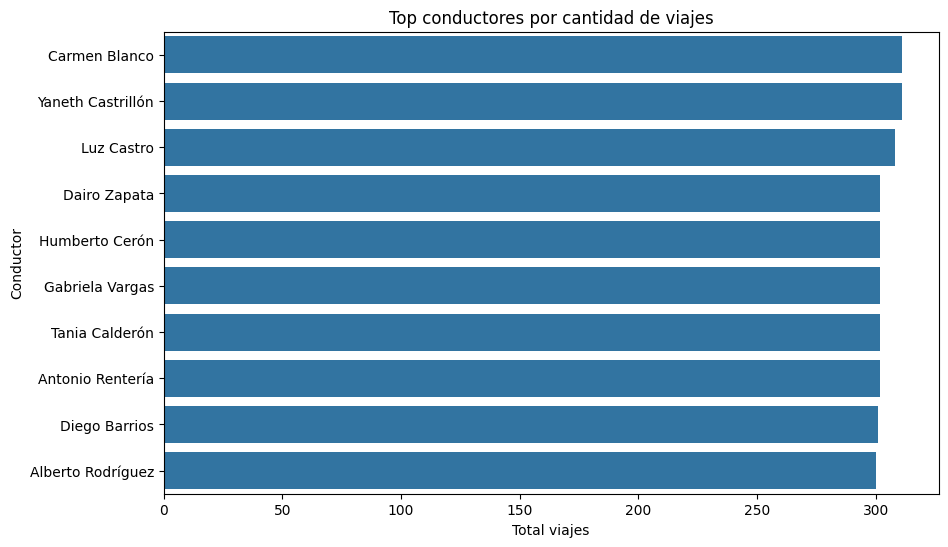

In [22]:
df = df2.copy()
df = df.sort_values('total_trips', ascending=False)
top = df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top,
    x='total_trips',
    y=top['first_name'] + ' ' + top['last_name'])

plt.title('Top conductores por cantidad de viajes')
plt.xlabel('Total viajes')
plt.ylabel('Conductor')

plt.show()

## **Análisis de resultados**
**Los resultados muestran que los conductores con mayor actividad registran alrededor de 300 viajes, como es el caso de Carmen Blanco y Yaneth Castrillón con 311 viajes cada una. En general, la distribución de viajes parece bastante homogénea entre los conductores. Desde una perspectiva de negocio, esto sugiere que la empresa está realizando una asignación relativamente equilibrada de los viajes, evitando sobrecargas significativas. Aunque tambien pudimos notar algunos conductores con 0 viajes**

**El tiempo de ejecución de la consulta es de aproximadamente 29.154 ms, lo cual es mayor en comparación con la Query 1 debido al mayor volumen de datos involucrados, específicamente los 100,000 registros de la tabla trips. El plan de ejecución muestra un Seq Scan sobre esta tabla, lo que implica que PostgreSQL recorre completamente todos los registros para realizar la operación.**

## ________________________________________________________________
## **QUERY 3 – Promedio de peso transportado por tipo de vehículo**

## **Problema de negocio**

**FleetLogix necesita evaluar si su flota está siendo utilizada de manera eficiente en función de la capacidad de cada tipo de vehículo. Un uso ineficiente podría implicar costos innecesarios, como utilizar camiones grandes para cargas pequeñas o sobrecargar vehículos más pequeños. Esta consulta permite analizar el promedio de peso transportado por cada tipo de vehículo, proporcionando información clave para optimizar la asignación de recursos logísticos.**

In [23]:
query3 = """
SELECT 
    v.vehicle_type,
    AVG(t.total_weight_kg) AS avg_weight,
    COUNT(t.trip_id) AS total_trips
FROM vehicles v
JOIN trips t 
    ON v.vehicle_id = t.vehicle_id
GROUP BY v.vehicle_type
ORDER BY avg_weight DESC;
"""

df3 = pd.read_sql(query3, conexion)
df3.head()

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\3643266603.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = pd.read_sql(query3, conexion)


,vehicle_type,avg_weight,total_trips
0,Camión Grande,3253.863034,29204
1,Camión Mediano,1943.316070,25904
2,Van,975.479312,34419
3,Motocicleta,32.578921,10473


In [24]:
query3_explain = "EXPLAIN ANALYZE " + query3
plan3 = pd.read_sql(query3_explain, conexion)
print("\n".join(plan3['QUERY PLAN']))

Sort  (cost=3055.65..3055.66 rows=4 width=51) (actual time=34.598..34.599 rows=4 loops=1)
  Sort Key: (avg(t.total_weight_kg)) DESC
  Sort Method: quicksort  Memory: 25kB
  ->  HashAggregate  (cost=3055.56..3055.61 rows=4 width=51) (actual time=34.586..34.589 rows=4 loops=1)
        Group Key: v.vehicle_type
        Batches: 1  Memory Usage: 24kB
        ->  Hash Join  (cost=6.50..2305.56 rows=100000 width=21) (actual time=0.059..18.977 rows=100000 loops=1)
              Hash Cond: (t.vehicle_id = v.vehicle_id)
              ->  Seq Scan on trips t  (cost=0.00..2031.00 rows=100000 width=14) (actual time=0.009..3.761 rows=100000 loops=1)
              ->  Hash  (cost=4.00..4.00 rows=200 width=15) (actual time=0.041..0.041 rows=200 loops=1)
                    Buckets: 1024  Batches: 1  Memory Usage: 18kB
                    ->  Seq Scan on vehicles v  (cost=0.00..4.00 rows=200 width=15) (actual time=0.008..0.022 rows=200 loops=1)
Planning Time: 0.219 ms
Execution Time: 34.647 ms


C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\37879813.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plan3 = pd.read_sql(query3_explain, conexion)


## **Análisis de resultados**
**Los resultados muestran que los camiones grandes transportan en promedio aproximadamente 3253 kg, seguidos por los camiones medianos con cerca de 1943 kg, las vans con aproximadamente 975 kg y finalmente las motocicletas con alrededor de 32 kg. Estos valores son coherentes con la capacidad esperada de cada tipo de vehículo. Desde el punto de vista del negocio, esto indica que la empresa está utilizando correctamente su flota, asignando cargas más pesadas a vehículos de mayor capacidad y cargas ligeras a vehículos más pequeños.**

**El tiempo de ejecución registrado es de aproximadamente 34.647 ms, siendo la consulta más costosa de las tres analizadas. Esto se debe principalmente al Seq Scan sobre la tabla trips, que contiene 100,000 registros.**

## ________________________________________________________________
## **QUERY 4 - Promedio de entregas por conductor (últimos 6 meses)**

## **Problema de negocio**

**FleetLogix requiere evaluar la productividad reciente de sus conductores para tomar decisiones basadas en desempeño actual. Analizar el promedio de entregas por viaje en los últimos seis meses permite identificar qué tan eficientes son los conductores en la gestión de entregas, facilitando la optimización de rutas y la asignación de recursos**

In [25]:
query4 = """
SELECT 
    d.driver_id,
    d.first_name,
    d.last_name,
    COUNT(del.delivery_id) AS total_deliveries,
    COUNT(DISTINCT t.trip_id) AS total_trips,
    COUNT(del.delivery_id)::decimal / COUNT(DISTINCT t.trip_id) AS avg_deliveries_per_trip
FROM drivers d
JOIN trips t ON d.driver_id = t.driver_id
JOIN deliveries del ON t.trip_id = del.trip_id
WHERE t.departure_datetime >= NOW() - INTERVAL '6 months'
GROUP BY d.driver_id, d.first_name, d.last_name
HAVING COUNT(DISTINCT t.trip_id) > 0
ORDER BY avg_deliveries_per_trip DESC;
"""
df4 = pd.read_sql(query4, conexion)
df4.head()

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\387976919.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df4 = pd.read_sql(query4, conexion)


,driver_id,first_name,last_name,total_deliveries,total_trips,avg_deliveries_per_trip
0,510,Mauricio,Díaz,217,49,4.428571
1,561,Alexander,Torres,206,47,4.382979
2,486,Mery,Ruiz,241,55,4.381818
3,451,Juan,Rodríguez,183,42,4.357143
4,706,Estella,Ramos,196,45,4.355556


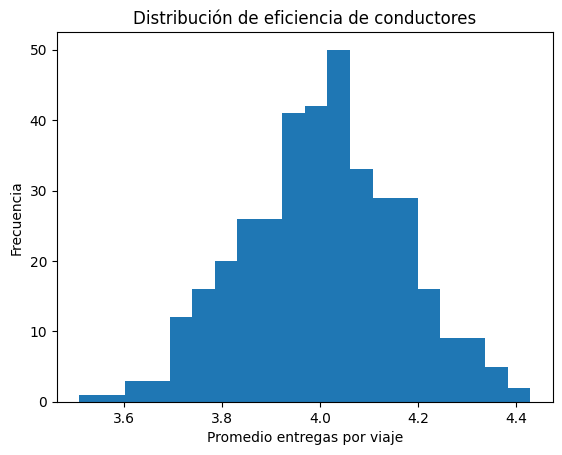

In [26]:
plt.figure()
plt.hist(df4['avg_deliveries_per_trip'], bins=20)
plt.xlabel("Promedio entregas por viaje")
plt.ylabel("Frecuencia")
plt.title("Distribución de eficiencia de conductores")
plt.show()

In [27]:
explain4 = "EXPLAIN ANALYZE " + query4
plan4 = pd.read_sql(explain4, conexion)
print("\n".join(plan4['QUERY PLAN']))

Sort  (cost=24586.05..24586.38 rows=133 width=66) (actual time=133.151..133.162 rows=373 loops=1)
  Sort Key: (((count(del.delivery_id))::numeric / (count(DISTINCT t.trip_id))::numeric)) DESC
  Sort Method: quicksort  Memory: 50kB
  ->  GroupAggregate  (cost=23795.20..24581.35 rows=133 width=66) (actual time=119.779..133.012 rows=373 loops=1)
        Group Key: d.driver_id
        Filter: (count(DISTINCT t.trip_id) > 0)
        ->  Sort  (cost=23795.20..23990.24 rows=78016 width=26) (actual time=119.721..126.427 rows=77269 loops=1)
              Sort Key: d.driver_id, t.trip_id
              Sort Method: external merge  Disk: 2920kB
              ->  Hash Join  (cost=3038.80..15586.82 rows=78016 width=26) (actual time=56.163..81.938 rows=77269 loops=1)
                    Hash Cond: (t.driver_id = d.driver_id)
                    ->  Hash Join  (cost=3024.80..15365.86 rows=78016 width=12) (actual time=56.078..73.701 rows=77269 loops=1)
                          Hash Cond: (del.trip_id 

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\4030497987.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plan4 = pd.read_sql(explain4, conexion)


## **Análisis de resultados**
**Los resultados muestran que el promedio de entregas por viaje se mantiene alrededor de 4 para la mayoría de los conductores, con un valor máximo de aproximadamente 4.43 y un mínimo cercano a 3.51. Esto indica una operación bastante consistente y alineada con la lógica del negocio, donde cada viaje genera entre 2 y 6 entregas. No se observan desviaciones significativas**

**El tiempo de ejecución fue de aproximadamente 143.537 ms, siendo una consulta relativamente costosa. El plan muestra múltiples Hash Join y un Seq Scan sobre la tabla deliveries con más de 400,000 registros, lo que representa el principal costo.**

## ________________________________________________________________
## **QUERY 5 – Rutas más utilizadas**

## **Problema de negocio**

**FleetLogix necesita identificar cuáles son las rutas más utilizadas para priorizar recursos, optimizar la planificación logística y detectar patrones de demanda entre ciudades. Esto permite enfocar esfuerzos en los corredores más críticos del negocio.**

In [28]:
query5 = """
SELECT 
    r.origin_city || ' - ' || r.destination_city AS route,
    COUNT(t.trip_id) AS total_trips
FROM routes r
JOIN trips t ON r.route_id = t.route_id
GROUP BY route
ORDER BY total_trips DESC
LIMIT 10;
"""
df5 = pd.read_sql(query5, conexion)
df5.head()

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\3810223866.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df5 = pd.read_sql(query5, conexion)


,route,total_trips
0,Cartagena - Bogotá,6362
1,Bogotá - Barranquilla,6325
2,Bogotá - Cartagena,6320
3,Bogotá - Cali,6260
4,Bogotá - Medellín,6237


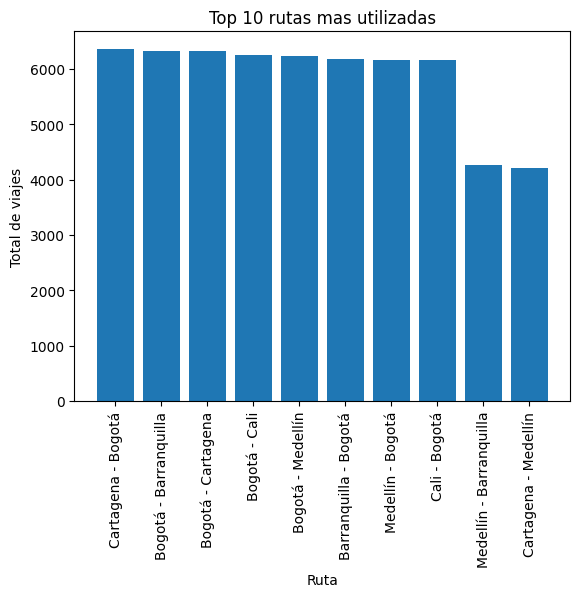

In [33]:
plt.figure()
plt.bar(df5['route'], df5['total_trips'])
plt.xticks(rotation=90)
plt.xlabel("Ruta")
plt.ylabel("Total de viajes")
plt.title("Top 10 rutas mas utilizadas")
plt.show()

In [30]:
explain5 = "EXPLAIN ANALYZE " + query5
plan5 = pd.read_sql(explain5, conexion)
print("\n".join(plan5['QUERY PLAN']))

Limit  (cost=3318.89..3318.90 rows=5 width=40) (actual time=35.063..35.067 rows=10 loops=1)
  ->  Sort  (cost=3318.89..3318.90 rows=5 width=40) (actual time=35.062..35.065 rows=10 loops=1)
        Sort Key: (count(t.trip_id)) DESC
        Sort Method: quicksort  Memory: 26kB
        ->  HashAggregate  (cost=3318.75..3318.83 rows=5 width=40) (actual time=35.047..35.052 rows=20 loops=1)
              Group Key: (((r.origin_city)::text || ' - '::text) || (r.destination_city)::text)
              Batches: 1  Memory Usage: 24kB
              ->  Hash Join  (cost=2.08..2818.75 rows=100000 width=36) (actual time=0.024..22.770 rows=100000 loops=1)
                    Hash Cond: (t.route_id = r.route_id)
                    ->  Seq Scan on trips t  (cost=0.00..2031.00 rows=100000 width=8) (actual time=0.008..3.974 rows=100000 loops=1)
                    ->  Hash  (cost=1.48..1.48 rows=48 width=22) (actual time=0.012..0.013 rows=48 loops=1)
                          Buckets: 1024  Batches: 1  M

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\3429183771.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plan5 = pd.read_sql(explain5, conexion)


## **Análisis de resultados**
**Los resultados muestran que rutas como Cartagena–Bogotá y Bogotá–Barranquilla presentan el mayor número de viajes, superando los 2100 registros. Esto indica que estas conexiones son altamente demandadas dentro de la operación logística.**

**El tiempo de ejecución fue de aproximadamente 35.098 ms. El plan muestra un Seq Scan sobre la tabla trips con 100,000 registros, seguido de un Hash Join con la tabla routes. Posteriormente se realiza un HashAggregate para agrupar los resultados**

## ________________________________________________________________
## **QUERY 6 – Conductores con más de 1000 entregas**

## **Problema de negocio**

**La empresa necesita identificar a los conductores con mayor volumen de entregas para evaluar desempeño, reconocer eficiencia operativa y detectar posibles sobrecargas laborales. Esta información es clave para la gestión del talento y la planificación de recursos humanos.**

In [35]:
query6 = """
SELECT 
    d.driver_id,
    d.first_name || ' ' || d.last_name AS driver,
    COUNT(del.delivery_id) AS total_deliveries
FROM drivers d
JOIN trips t ON d.driver_id = t.driver_id
JOIN deliveries del ON t.trip_id = del.trip_id
GROUP BY d.driver_id, driver
HAVING COUNT(del.delivery_id) > 1000
ORDER BY total_deliveries DESC
LIMIT 10;
"""
df6 = pd.read_sql(query6, conexion)
df6.head(5)

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\3710756346.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df6 = pd.read_sql(query6, conexion)


,driver_id,driver,total_deliveries
0,717,Luz Castro,1264
1,613,Carmen Blanco,1261
2,537,Yaneth Castrillón,1256
3,727,Tania Calderón,1227
4,747,Diego Barrios,1224


In [38]:
explain6 = "EXPLAIN ANALYZE " + query6
plan6 = pd.read_sql(explain6, conexion)
print("\n".join(plan6['QUERY PLAN']))

Limit  (cost=15420.40..15420.42 rows=10 width=44) (actual time=113.559..116.924 rows=10 loops=1)
  ->  Sort  (cost=15420.40..15420.73 rows=133 width=44) (actual time=113.559..116.923 rows=10 loops=1)
        Sort Key: (count(del.delivery_id)) DESC
        Sort Method: top-N heapsort  Memory: 25kB
        ->  Finalize GroupAggregate  (cost=15312.52..15417.52 rows=133 width=44) (actual time=113.208..116.888 rows=325 loops=1)
              Group Key: d.driver_id, ((((d.first_name)::text || ' '::text) || (d.last_name)::text))
              Filter: (count(del.delivery_id) > 1000)
              Rows Removed by Filter: 48
              ->  Gather Merge  (cost=15312.52..15405.86 rows=800 width=44) (actual time=113.202..116.738 rows=1119 loops=1)
                    Workers Planned: 2
                    Workers Launched: 2
                    ->  Sort  (cost=14312.49..14313.49 rows=400 width=44) (actual time=91.551..91.569 rows=373 loops=3)
                          Sort Key: d.driver_id, ((((

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\2567214821.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plan6 = pd.read_sql(explain6, conexion)


## **Análisis de resultados**
**Se identifican múltiples conductores con más de 1000 entregas, destacando algunos con valores superiores a 1200. Esto indica un alto nivel de actividad y productividad dentro de la operación. La diferencia entre los conductores no es extrema, lo que sugiere una distribución relativamente equilibrada del trabajo.**

**El tiempo de ejecución fue de aproximadamente 116.997 ms. El plan muestra el uso de procesamiento paralelo (Parallel Seq Scan y Gather Merge), lo que indica que PostgreSQL optimiza la consulta distribuyendo la carga entre múltiples workers.**

## ________________________________________________________________
## **QUERY 7 – Entregas con retraso**

## **Problema de negocio**

**FleetLogix necesita monitorear la puntualidad en las entregas para garantizar la calidad del servicio. Identificar entregas con retraso permite detectar problemas operativos, evaluar el desempeño logístico y mejorar la experiencia del cliente.**

In [39]:
query7 = """
SELECT 
    (delivered_datetime - scheduled_datetime) AS delay_time
FROM deliveries
WHERE delivered_datetime IS NOT NULL
AND delivered_datetime > scheduled_datetime;
"""
df7 = pd.read_sql(query7, conexion)
df7.head()

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\1940330696.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df7 = pd.read_sql(query7, conexion)


,delay_time
0,0 days 00:10:00
1,0 days 00:18:00
2,0 days 00:03:00
3,0 days 00:16:00
4,0 days 00:30:00


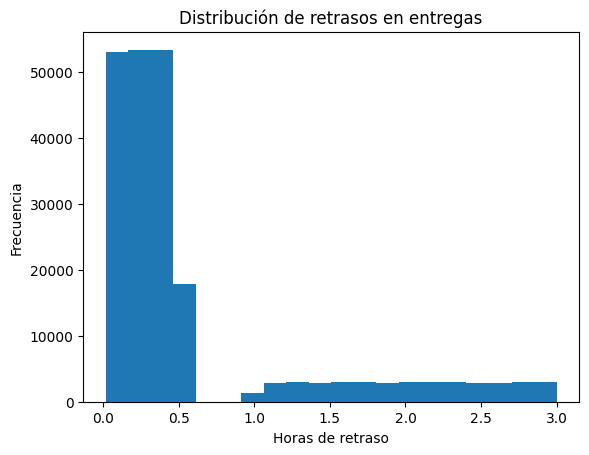

In [41]:
delay_hours = df7['delay_time'].dt.total_seconds() / 3600

plt.figure()
plt.hist(delay_hours, bins=20)
plt.xlabel("Horas de retraso")
plt.ylabel("Frecuencia")
plt.title("Distribución de retrasos en entregas")
plt.show()

In [ ]:
explain6 = "EXPLAIN ANALYZE " + query6
plan6 = pd.read_sql(explain6, conexion)
print("\n".join(plan6['QUERY PLAN']))

In [40]:
explain7 = "EXPLAIN ANALYZE " + query7
plan7 = pd.read_sql(explain7, conexion)
print("\n".join(plan7['QUERY PLAN']))

Seq Scan on deliveries  (cost=0.00..12624.35 rows=133334 width=16) (actual time=0.032..55.267 rows=217089 loops=1)
  Filter: ((delivered_datetime IS NOT NULL) AND (delivered_datetime > scheduled_datetime))
  Rows Removed by Filter: 182912
Planning Time: 0.095 ms
Execution Time: 59.046 ms


C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\2940244914.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plan7 = pd.read_sql(explain7, conexion)


## **Análisis de resultados**
**Los resultados de la grafica y los datos muestran múltiples entregas con un retraso menor a 30 min respecto a la hora programada. Este patrón uniforme sugiere que los retrasos son aleatorios**

**El tiempo de ejecución fue de aproximadamente 59.046 ms. El plan muestra un Parallel Seq Scan sobre la tabla deliveries, filtrando más de 400,000 registros.**

## ________________________________________________________________
## **QUERY 8 – Consumo promedio de combustible por ruta**

## **Problema de negocio**

**La empresa necesita analizar el consumo de combustible por ruta para optimizar costos operativos y detectar rutas ineficientes. Este indicador permite tomar decisiones estratégicas relacionadas con la planificación logística y el control de gastos.**

In [42]:
query8 = """
SELECT 
    r.origin_city || ' - ' || r.destination_city AS route,
    AVG(t.fuel_consumed_liters) AS avg_fuel
FROM routes r
JOIN trips t ON r.route_id = t.route_id
WHERE t.status = 'completed'
GROUP BY route
ORDER BY avg_fuel DESC
LIMIT 10;
"""
df8 = pd.read_sql(query8, conexion)
df8

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\3843511975.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df8 = pd.read_sql(query8, conexion)


,route,avg_fuel
0,Cali - Cartagena,129.919074
1,Cartagena - Cali,126.670324
2,Cartagena - Bogotá,121.069143
3,Bogotá - Cartagena,117.896663
4,Cartagena - Medellín,61.214882
5,Barranquilla - Bogotá,59.763525
6,Barranquilla - Cali,59.061599
7,Bogotá - Barranquilla,57.841519
8,Medellín - Barranquilla,57.578917
9,Medellín - Cartagena,56.997981


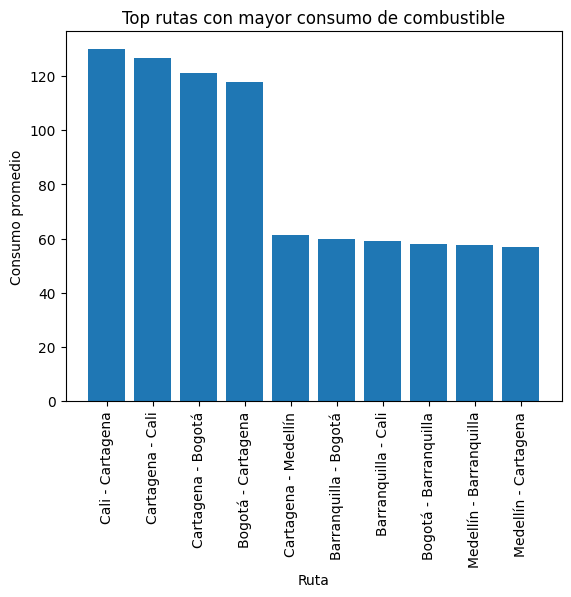

In [45]:
plt.figure()
plt.bar(df8['route'], df8['avg_fuel'])
plt.xticks(rotation=90)
plt.xlabel("Ruta")
plt.ylabel("Consumo promedio")
plt.title("Top rutas con mayor consumo de combustible")
plt.show()

In [ ]:
explain8 = "EXPLAIN ANALYZE " + query8
plan8 = pd.read_sql(explain8, conexion)
print("\n".join(plan8['QUERY PLAN']))

Limit  (cost=3525.58..3525.59 rows=5 width=64) (actual time=54.003..58.498 rows=10 loops=1)
  ->  Sort  (cost=3525.58..3525.59 rows=5 width=64) (actual time=54.002..58.496 rows=10 loops=1)
        Sort Key: (avg(t.fuel_consumed_liters)) DESC
        Sort Method: quicksort  Memory: 26kB
        ->  Finalize GroupAggregate  (cost=3524.82..3525.52 rows=5 width=64) (actual time=53.945..58.481 rows=20 loops=1)
              Group Key: ((((r.origin_city)::text || ' - '::text) || (r.destination_city)::text))
              ->  Gather Merge  (cost=3524.82..3525.40 rows=5 width=64) (actual time=53.926..58.439 rows=40 loops=1)
                    Workers Planned: 1
                    Workers Launched: 1
                    ->  Sort  (cost=2524.81..2524.82 rows=5 width=64) (actual time=34.003..34.006 rows=20 loops=2)
                          Sort Key: ((((r.origin_city)::text || ' - '::text) || (r.destination_city)::text))
                          Sort Method: quicksort  Memory: 27kB
          

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\1258854007.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plan8 = pd.read_sql(explain8, conexion)


## **Análisis de resultados**
**Los resultados muestran que algunas rutas, como Cali–Cartagena y Cartagena–Cali, presentan los mayores niveles de consumo promedio de combustible, superando los 120 litros por viaje. Esto indica que estas rutas son más exigentes en términos de consumo, posiblemente debido a su distancia o condiciones operativas.**

**El tiempo de ejecución fue de aproximadamente 58.570 ms. El plan muestra un Seq Scan sobre la tabla trips filtrando por estado completado, seguido de un Hash Join con la tabla routes y una agregación.**

## ________________________________________________________________
## **QUERY 9 – EFICIENCIA DE USO DE CAPACIDAD**

## **Problema de negocio**

**FleetLogix necesita evaluar qué tan eficientemente está utilizando la capacidad de carga de sus vehículos. Un uso cercano al 100% implica operaciones optimizadas, mientras que valores bajos indicarían subutilización y pérdidas operativas.**

In [46]:
query9 = """
SELECT 
    v.vehicle_type,
    t.trip_id,
    t.total_weight_kg,
    v.capacity_kg,
    (t.total_weight_kg / v.capacity_kg) AS utilization_rate,
    RANK() OVER (
        PARTITION BY v.vehicle_type 
        ORDER BY (t.total_weight_kg / v.capacity_kg) DESC
    ) AS efficiency_rank
FROM trips t
JOIN vehicles v ON t.vehicle_id = v.vehicle_id
WHERE v.capacity_kg > 0;
"""

df_q9 = pd.read_sql(query9, conexion)
df_q9.head()

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\3085480217.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q9 = pd.read_sql(query9, conexion)


,vehicle_type,trip_id,total_weight_kg,capacity_kg,utilization_rate,efficiency_rank
0,Camión Grande,132508,4499.95,5000.0,0.899990,1
1,Camión Grande,159063,4499.93,5000.0,0.899986,2
2,Camión Grande,154727,4499.89,5000.0,0.899978,3
3,Camión Grande,168611,4499.81,5000.0,0.899962,4
4,Camión Grande,141084,4499.81,5000.0,0.899962,4


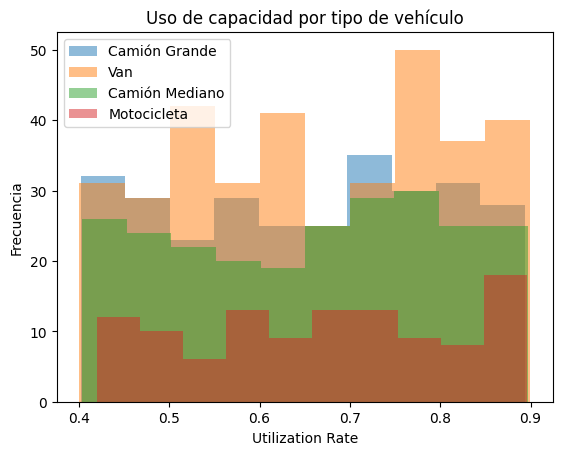

In [48]:
df_q9_sample = df_q9.sample(1000)

plt.figure()
for vtype in df_q9_sample['vehicle_type'].unique():
    subset = df_q9_sample[df_q9_sample['vehicle_type'] == vtype]
    plt.hist(subset['utilization_rate'], alpha=0.5, label=vtype)

plt.title("Uso de capacidad por tipo de vehículo")
plt.xlabel("Utilization Rate")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

In [47]:
explain_q9 = "EXPLAIN ANALYZE " + query9
plan_q9 = pd.read_sql(explain_q9, conexion)

print("\n".join(plan_q9['QUERY PLAN']))

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\2975197558.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plan_q9 = pd.read_sql(explain_q9, conexion)


WindowAgg  (cost=14623.40..16873.38 rows=100000 width=66) (actual time=164.395..210.609 rows=100000 loops=1)
  ->  Sort  (cost=14623.38..14873.38 rows=100000 width=58) (actual time=164.379..178.181 rows=100000 loops=1)
        Sort Key: v.vehicle_type, ((t.total_weight_kg / v.capacity_kg)) DESC
        Sort Method: external merge  Disk: 4760kB
        ->  Hash Join  (cost=7.00..2556.06 rows=100000 width=58) (actual time=0.078..31.821 rows=100000 loops=1)
              Hash Cond: (t.vehicle_id = v.vehicle_id)
              ->  Seq Scan on trips t  (cost=0.00..2031.00 rows=100000 width=14) (actual time=0.012..4.215 rows=100000 loops=1)
              ->  Hash  (cost=4.50..4.50 rows=200 width=20) (actual time=0.053..0.054 rows=200 loops=1)
                    Buckets: 1024  Batches: 1  Memory Usage: 19kB
                    ->  Seq Scan on vehicles v  (cost=0.00..4.50 rows=200 width=20) (actual time=0.006..0.031 rows=200 loops=1)
                          Filter: (capacity_kg > '0'::numeri

## **Análisis de resultados**
**Los resultados muestran que los vehículos, especialmente los de tipo Van, operan con una tasa de utilización cercana al 0.9 (90%), lo cual indica un alto nivel de eficiencia en la carga transportada. Este comportamiento es consistente entre múltiples viajes**

**El plan de ejecución muestra un Hash Join entre las tablas trips y vehicles, seguido de una operación de ordenamiento (Sort) necesaria para aplicar la función de ventana RANK(). Este ordenamiento utilizó un método de external merge con uso de disco, lo que indica que la memoria disponible no fue suficiente para procesar los 100,000 registros en RAM.**

## ________________________________________________________________
## **QUERY 10 – COSTO DE MANTENIMIENTO POR VIAJE**

## **Problema de negocio**

**La empresa busca identificar qué vehículos generan mayores costos de mantenimiento en relación a su uso. Esto permite detectar unidades ineficientes o costosas que podrían requerir reemplazo o mantenimiento preventivo más eficiente.**

In [49]:
query10 = """
WITH vehicle_usage AS (
    SELECT 
        v.vehicle_id,
        COUNT(t.trip_id) AS total_trips
    FROM vehicles v
    LEFT JOIN trips t ON v.vehicle_id = t.vehicle_id
    GROUP BY v.vehicle_id
),
maintenance_costs AS (
    SELECT 
        vehicle_id,
        SUM(cost) AS total_maintenance_cost
    FROM maintenance
    GROUP BY vehicle_id
)
SELECT 
    v.vehicle_id,
    v.vehicle_type,
    vu.total_trips,
    mc.total_maintenance_cost,
    (mc.total_maintenance_cost / NULLIF(vu.total_trips, 0)) AS cost_per_trip
FROM vehicles v
LEFT JOIN vehicle_usage vu ON v.vehicle_id = vu.vehicle_id
LEFT JOIN maintenance_costs mc ON v.vehicle_id = mc.vehicle_id
ORDER BY cost_per_trip DESC NULLS LAST;
"""

df_q10 = pd.read_sql(query10, conexion)
df_q10.head()

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\396600321.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q10 = pd.read_sql(query10, conexion)


,vehicle_id,vehicle_type,total_trips,total_maintenance_cost,cost_per_trip
0,343,Camión Grande,544,10604389.21,19493.362518
1,300,Camión Mediano,520,9881661.40,19003.195000
2,234,Van,558,10075791.71,18056.974391
3,323,Camión Grande,528,9515960.29,18022.652064
4,297,Camión Grande,545,9783356.57,17951.112972


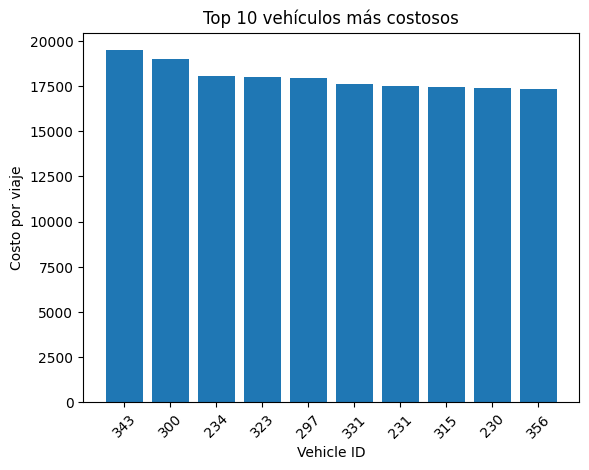

In [51]:
df_q10_top = df_q10.sort_values(by="cost_per_trip", ascending=False).head(10)

plt.figure()
plt.bar(df_q10_top["vehicle_id"].astype(str), df_q10_top["cost_per_trip"])

plt.title("Top 10 vehículos más costosos")
plt.xlabel("Vehicle ID")
plt.ylabel("Costo por viaje")
plt.xticks(rotation=45)

plt.show()

In [50]:
explain_q10 = "EXPLAIN ANALYZE " + query10
plan_q10 = pd.read_sql(explain_q10, conexion)

print("\n".join(plan_q10['QUERY PLAN']))

Sort  (cost=2991.41..2991.91 rows=200 width=87) (actual time=26.445..26.456 rows=200 loops=1)
  Sort Key: ((mc.total_maintenance_cost / (NULLIF(vu.total_trips, 0))::numeric)) DESC NULLS LAST
  Sort Method: quicksort  Memory: 37kB
  ->  Hash Left Join  (cost=2977.20..2983.77 rows=200 width=87) (actual time=26.304..26.399 rows=200 loops=1)
        Hash Cond: (v.vehicle_id = vu.vehicle_id)
        ->  Hash Left Join  (cost=165.13..169.67 rows=200 width=47) (actual time=1.224..1.272 rows=200 loops=1)
              Hash Cond: (v.vehicle_id = mc.vehicle_id)
              ->  Seq Scan on vehicles v  (cost=0.00..4.00 rows=200 width=15) (actual time=0.006..0.015 rows=200 loops=1)
              ->  Hash  (cost=162.87..162.87 rows=181 width=36) (actual time=1.206..1.208 rows=181 loops=1)
                    Buckets: 1024  Batches: 1  Memory Usage: 17kB
                    ->  Subquery Scan on mc  (cost=158.80..162.87 rows=181 width=36) (actual time=1.117..1.173 rows=181 loops=1)
                 

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_18540\2132528099.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plan_q10 = pd.read_sql(explain_q10, conexion)


## **Análisis de resultados**
**Se observa que algunos vehículos presentan un costo por viaje significativamente elevado (alrededor de 19,000 unidades monetarias), especialmente en categorías como Camión Grande y Camión Mediano. Esto indica que, aunque estos vehículos tienen alta capacidad, también generan mayores costos operativos.**

**El plan utiliza múltiples HashAggregate para calcular tanto el uso (trips) como los costos de mantenimiento. Luego se aplican Hash Join para combinar los resultados. A pesar de la complejidad lógica, el tiempo de ejecución es relativamente bajo (~27 ms) gracias a que las agregaciones reducen significativamente el volumen de datos antes de los joins finales**

## ________________________________________________________________
## **QUERY 11 – SUBCONSULTA CORRELACIONADA**

## **Problema de negocio**

**Se busca identificar entregas cuyo peso esté por encima del promedio de su propio viaje, con el objetivo de detectar paquetes atípicos que puedan afectar la logística o distribución de carga.**

In [ ]:
query11 = """
SELECT 
    d.delivery_id,
    d.trip_id,
    d.package_weight_kg
FROM deliveries d
WHERE d.package_weight_kg > (
    SELECT AVG(d2.package_weight_kg)
    FROM deliveries d2
    WHERE d2.trip_id = d.trip_id
);
"""

try:
    df_q11 = pd.read_sql(query11, conexion)
except:
    conexion.rollback()
    df_q11 = pd.read_sql(query11, conexion)

In [ ]:
explain_q11 = "EXPLAIN ANALYZE " + query11
plan_q11 = pd.read_sql(explain_q11, conexion)

print("\n".join(plan_q11['QUERY PLAN']))

## **Análisis de resultados**
**Los resultados muestran múltiples entregas cuyo peso supera el promedio del viaje correspondiente, lo cual indica una distribución desigual de carga entre paquetes. Este tipo de análisis permite identificar posibles ineficiencias en la distribución o la presencia de cargas atípicas que podrían afectar la operación logística.**

**Esta consulta presentó un rendimiento extremadamente bajo, llegando a tardar más de un minuto antes de ser cancelada. Esto se debe a la naturaleza de la subconsulta correlacionada, la cual ejecuta el cálculo del promedio para cada fila de la tabla deliveries (400,000 registros), generando un costo computacional muy alto.**

## ________________________________________________________________
## **QUERY 12 – PIVOT DE ENTREGAS POR VIAJE**

## **Problema de negocio**

**FleetLogix necesita evaluar la calidad del servicio por viaje, identificando cuántas entregas fueron completadas, pendientes y cuántas cuentan con firma del cliente.**

In [3]:
query12 = """
SELECT 
    t.trip_id,
    COUNT(CASE WHEN d.delivery_status = 'delivered' THEN 1 END) AS delivered_count,
    COUNT(CASE WHEN d.delivery_status = 'pending' THEN 1 END) AS pending_count,
    COUNT(CASE WHEN d.recipient_signature = TRUE THEN 1 END) AS signed_count
FROM trips t
JOIN deliveries d ON t.trip_id = d.trip_id
GROUP BY t.trip_id
ORDER BY delivered_count DESC;
"""

df_q12 = pd.read_sql(query12, conexion)
df_q12.head()

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_20920\2392733729.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q12 = pd.read_sql(query12, conexion)


,trip_id,delivered_count,pending_count,signed_count
0,123407,6,0,6
1,129281,6,0,6
2,177996,6,0,6
3,193915,6,0,5
4,133996,6,0,5


In [4]:
explain_q12 = "EXPLAIN ANALYZE " + query12
plan_q12 = pd.read_sql(explain_q12, conexion)

print("\n".join(plan_q12['QUERY PLAN']))

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_20920\74449020.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  plan_q12 = pd.read_sql(explain_q12, conexion)


Sort  (cost=60852.21..61102.21 rows=100000 width=28) (actual time=335.947..341.108 rows=99950 loops=1)
  Sort Key: (count(CASE WHEN ((d.delivery_status)::text = 'delivered'::text) THEN 1 ELSE NULL::integer END)) DESC
  Sort Method: external merge  Disk: 4120kB
  ->  HashAggregate  (cost=45247.13..50153.39 rows=100000 width=28) (actual time=218.676..313.407 rows=99950 loops=1)
        Group Key: t.trip_id
        Batches: 5  Memory Usage: 8241kB  Disk Usage: 7840kB
        ->  Hash Join  (cost=3281.00..15622.06 rows=400001 width=15) (actual time=19.025..127.548 rows=400001 loops=1)
              Hash Cond: (d.trip_id = t.trip_id)
              ->  Seq Scan on deliveries d  (cost=0.00..11291.01 rows=400001 width=15) (actual time=0.015..29.308 rows=400001 loops=1)
              ->  Hash  (cost=2031.00..2031.00 rows=100000 width=4) (actual time=18.812..18.813 rows=100000 loops=1)
                    Buckets: 131072  Batches: 1  Memory Usage: 4540kB
                    ->  Seq Scan on trips

## **Análisis de resultados**
**Los resultados muestran viajes con hasta 6 entregas completadas y sin pendientes, lo cual indica un alto nivel de eficiencia operativa. Además, la presencia de firmas en la mayoría de entregas sugiere un buen nivel de cumplimiento en la validación de entregas.**

**El plan de ejecución evidencia un Hash Join entre trips y deliveries, seguido de un HashAggregate para agrupar por viaje. Debido al gran volumen de datos (400,000 entregas), la agregación requirió múltiples batches y uso de disco, lo que incrementó el tiempo de ejecución a aproximadamente 355.69 ms.**